In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings

warnings.filterwarnings('ignore')

print("==================================================")
print(" PHASE 4: MACHINE LEARNING MODEL (REGRESSION)")
print("==================================================")

# 1. Load the cleaned dataset
try:
    df = pd.read_csv('Clean.csv')
    df['Price_GBP'] = pd.to_numeric(df['Price_GBP'], errors='coerce')
    df['Stock_Quantity'] = pd.to_numeric(df['Stock_Quantity'], errors='coerce')
    df.dropna(inplace=True)
    print("Clean.csv loaded successfully!\n")
except FileNotFoundError:
    print("Error: Clean.csv not found. Please run Phase 2 first.")
    exit()

 PHASE 4: MACHINE LEARNING MODEL (REGRESSION)
Clean.csv loaded successfully!



In [4]:
# 2. FEATURE SELECTION (Predicting Price)
print("Preparing features and target variable...")

X = df[['Rating_Num', 'Stock_Quantity']]

y = df['Price_GBP']

Preparing features and target variable...


In [5]:
# 3. TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"Data Split Complete:")
print(f"- Training Samples: {X_train.shape[0]}")
print(f"- Testing Samples:  {X_test.shape[0]}\n")

Data Split Complete:
- Training Samples: 799
- Testing Samples:  200



In [6]:
# 4. MODEL TRAINING
print("Training the Random Forest Regressor...")

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

Training the Random Forest Regressor...


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [7]:
# 5. EVALUATION (Accuracy / RMSE / R²)
# Generate predictions on the unseen test data
y_pred = rf_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("--- OUTPUT -> ML Model Performance Metrics ---")
print(f"Root Mean Squared Error (RMSE): £{rmse:.2f}")
print(f"Mean Absolute Error (MAE):      £{mae:.2f}")
print(f"R-Squared (R²):                 {r2:.4f}")

--- OUTPUT -> ML Model Performance Metrics ---
Root Mean Squared Error (RMSE): £15.46
Mean Absolute Error (MAE):      £13.22
R-Squared (R²):                 -0.1955



Generating Performance Visualizations...


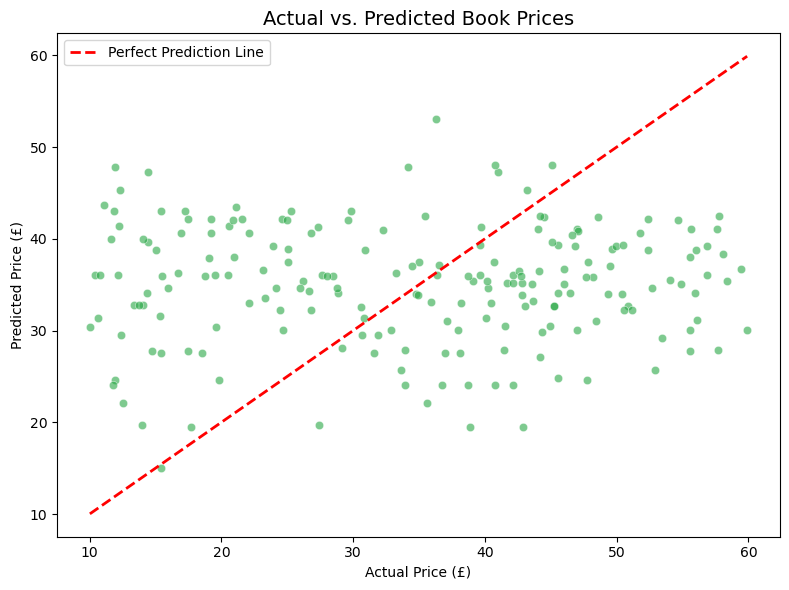

In [8]:
# 6. VISUALIZING MODEL PERFORMANCE
print("\nGenerating Performance Visualizations...")

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color='#28a745')

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', lw=2, label='Perfect Prediction Line')

plt.title('Actual vs. Predicted Book Prices', fontsize=14)
plt.xlabel('Actual Price (£)')
plt.ylabel('Predicted Price (£)')
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
# 7. EXPORT RESULTS
# Save the predictions back to a CSV for your final Dashboard
output_df = X_test.copy()
output_df['Actual_Price'] = y_test
output_df['Predicted_Price'] = y_pred
output_df.to_csv('Regression_Results.csv', index=False)
print("\nPhase 4 Complete! 'Regression_Results.csv' exported for your dashboard.")


Phase 4 Complete! 'Regression_Results.csv' exported for your dashboard.
